<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/Tp1_IA_TitanicDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Trabajo Práctico: Preprocesamiento de Datos para Machine Learning

📌 Objetivo

Aplicar técnicas de preprocesamiento de datos a un dataset real para prepararlo para un modelo predictivo. Los alumnos deben demostrar comprensión de:  

* Estandarización (eliminación de media y escalado de varianza)  

* Transformación no lineal  

* Normalización (Min-Max)  

* Codificación de características categóricas  

* Discretización

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler



In [ ]:
#'Titanic data set'

df = pd.read_csv('Titanic-Dataset.csv')
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Columnas:

PassengerID → ID del pasajero.

Survived → sobrevivio/no sobrevivio.

Pclass → tipo de clase (1/2/3).

Name → pasajero a bordo.

Sex → sexo.

age → edad.

SibSp → hermanos / matrimonos a bordo.

Peach → padres / hijos a bordo.

ticket → numero de ticket.

Fare → tarifa de ticket.

Cabin → cabina/habitación.

Embarked → puerto de embarque.




,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


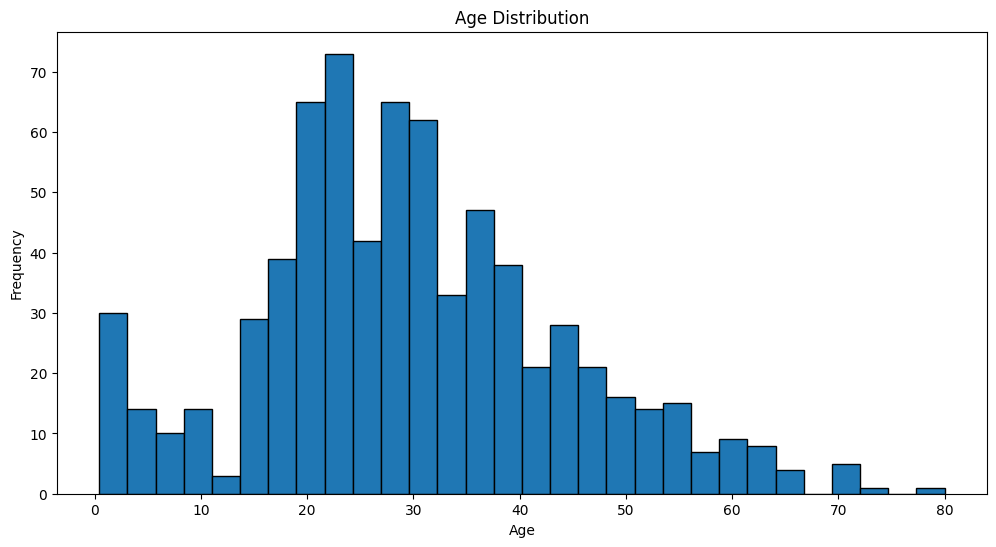

'→ NUmber of survived: 342 '

'→ Number of not survived: 549 '

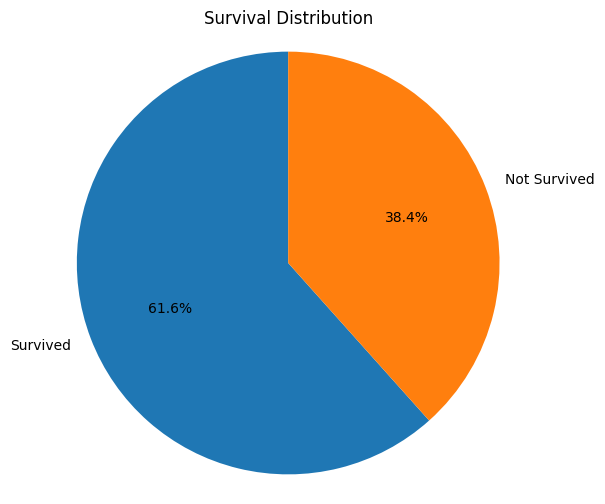

'→ Number of male: 577 '

'→ Number of female: 314 '

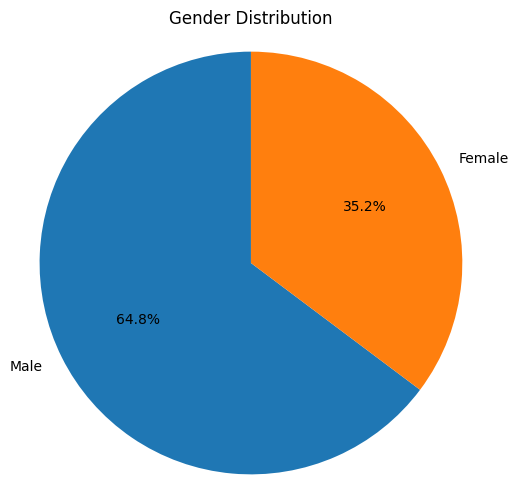

In [ ]:
#Paso 1 : explorar datos

display(df.describe())
display(df.isnull().sum())

plt.figure(figsize = (12,6))
plt.hist(df['Age'], bins = 30, edgecolor = 'black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

labels = ['Survived', 'Not Survived']
sizes = df['Survived'].value_counts()
colors = ['lightgreen', 'orange']
explode = (0.1, 0)
plt.figure(figsize = (6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Survival Distribution')

count_survided = df['Survived'].value_counts()[1]
count_not_survived = df['Survived'].value_counts()[0]

display(f"→ NUmber of survived: {count_survided} ")
display(f"→ Number of not survived: {count_not_survived} ")
plt.show()


labels = ['Male', 'Female']
sizes = df['Sex'].value_counts()
colors = ['lightblue', 'pink']
explode = (0.1,0)
plt.figure(figsize = (6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Gender Distribution')


count_male = df['Sex'].value_counts().iloc[0]
count_female = df['Sex'].value_counts().iloc[1]

display(f"→ Number of male: {count_male} ")
display(f"→ Number of female: {count_female} ")

plt.show()

(X_test_scaled) Media de precios de tarifas con datos escalados: -0.03662030245771497

(X_test_scaled) Desvio estandar: 0.7574637705789127

(X_train_scaled) Media de edades con datos escalados: 5.3639988830204194e-17

(X_train_scaled) Desvio estandar: 1.0



Text(0.5, 1.0, 'Estandarizado')

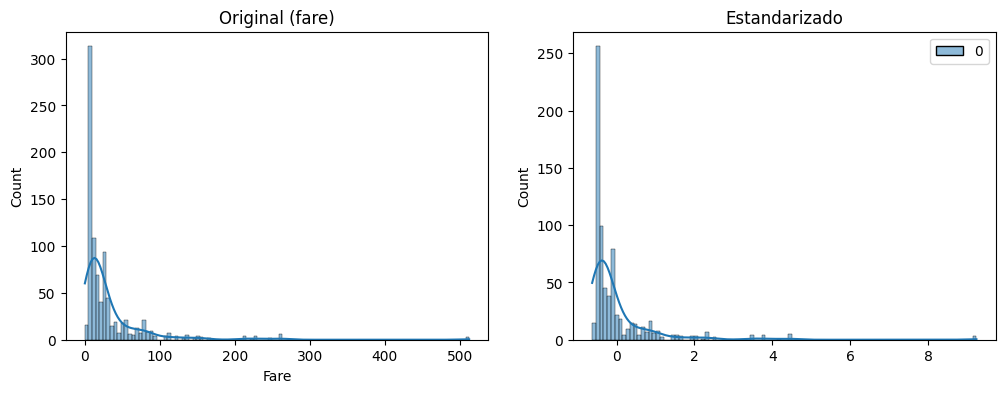

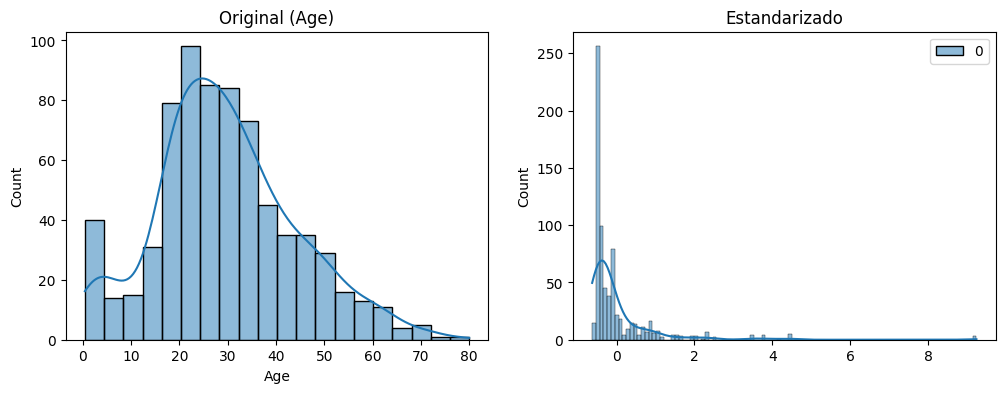

In [ ]:
#Aplicar tecnicas de preoprosesamiento en la columna 'fare' (tarifa del ticket) y 'Age'

X_train, X_test, y_train, y_test = train_test_split(df[['Fare']], df['Age'], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"(X_test_scaled) Media de precios de tarifas con datos escalados: {np.mean(X_test_scaled)}\n")
print(f"(X_test_scaled) Desvio estandar: {np.std(X_test_scaled)}\n")

print(f"(X_train_scaled) Media de edades con datos escalados: {np.mean(X_train_scaled)}\n")
print(f"(X_train_scaled) Desvio estandar: {np.std(X_train_scaled)}\n")


#Ploteos datos originales vs escalados (visualizar comparacion)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Fare'], kde=True, ax=ax1).set_title('Original (fare)')
sns.histplot(X_train_scaled, kde=True, ax=ax2).set_title('Estandarizado')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Age'], kde=True, ax=ax1).set_title('Original (Age)')
sns.histplot(X_train_scaled, kde=True, ax=ax2).set_title('Estandarizado')

Text(0.5, 1.0, 'Edad con Transformación Log')

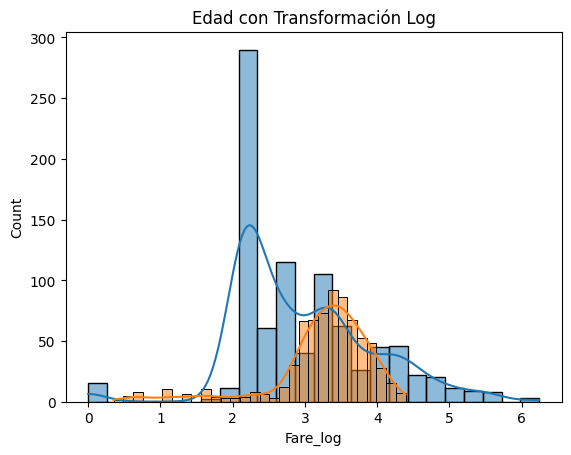

In [ ]:
#3. Transformación lineal

# Aplicar logaritmo
df['Fare_log'] = np.log1p(df['Fare'])
df['Age_log'] = np.log1p(df['Age'])

sns.histplot(df['Fare_log'], kde=True).set_title('Tarifa con Transformación Log')
sns.histplot(df['Age_log'], kde=True).set_title('Edad con Transformación Log')

In [ ]:
#4. Normalización
min_max_scaler_fare = MinMaxScaler()


# 2. Ajustar y transformar 'Fare' (set de entrenamiento y prueba)
X_train_minmax_Fare = min_max_scaler_fare.fit_transform(X_train[['Fare']])
X_test_minmax_Fare = min_max_scaler_fare.transform(X_test[['Fare']])


y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Verificación de rangos para 'Fare'
print(f"Mínimo en Train (Fare): {X_train_minmax_Fare.min()}") # Debe ser 0.0
print(f"Máximo en Train (Fare): {X_train_minmax_Fare.max()}") # Debe ser 1.0

print(f"Mínimo en Test (Fare): {X_test_minmax_Fare.min()}")
print(f"Máximo en Test (Fare): {X_test_minmax_Fare.max()}")


Mínimo en Train (Fare): 0.0
Máximo en Train (Fare): 1.0
Mínimo en Test (Fare): 0.0
Máximo en Test (Fare): 0.5121218935012878


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Codificar 'Embarked' (C, S, Q)
encoder_embarked = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
embarked_encoded = encoder_embarked.fit_transform(df[['Embarked']])
embarked_cols = encoder_embarked.get_feature_names_out(['Embarked'])

# Crear un DataFrame con las características codificadas de Embarked
df_embarked_encoded = pd.DataFrame(embarked_encoded, columns=embarked_cols, index=df.index)

# Codificar 'Sex'
encoder_sex = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
sex_encoded = encoder_sex.fit_transform(df[['Sex']])
sex_cols = encoder_sex.get_feature_names_out(['Sex'])

# Crear un DataFrame con las características codificadas de Sex
df_sex_encoded = pd.DataFrame(sex_encoded, columns=sex_cols, index=df.index)
df = pd.concat([df, df_embarked_encoded, df_sex_encoded], axis=1)

display(df[['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Sex_male', 'Sex_female']])

,Embarked_C,Embarked_Q,Embarked_S,Sex_male,Sex_female
0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...
886,0.0,0.0,1.0,1.0,0.0
887,0.0,0.0,1.0,0.0,1.0
888,0.0,0.0,1.0,0.0,1.0
889,1.0,0.0,0.0,1.0,0.0


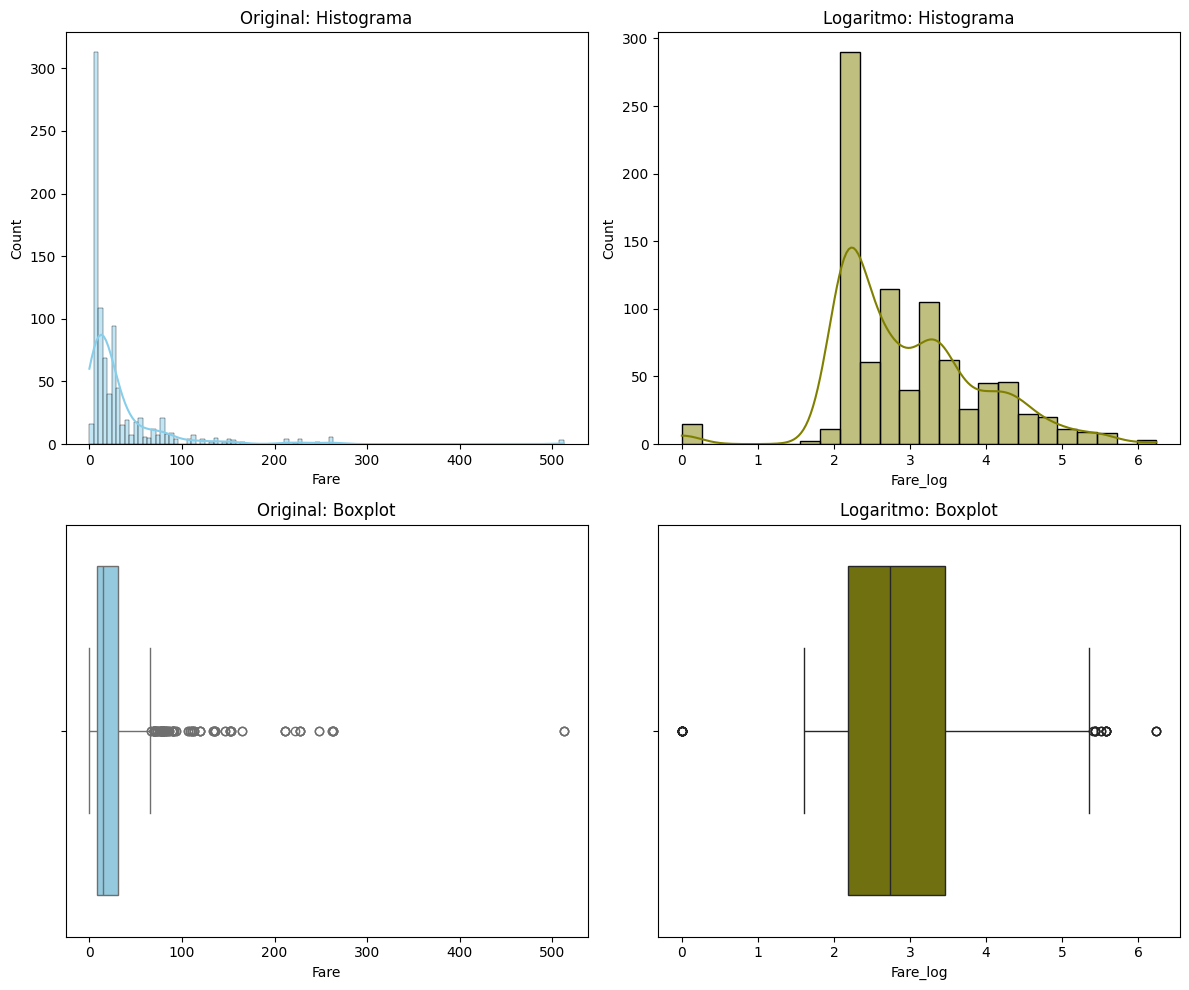

In [ ]:
#Comparación en 'Fare'
def comparar_transformacion(data_original, data_transformada, nombre_tecnica):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Histogramas
    sns.histplot(data_original, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title(f'Original: Histograma')

    sns.histplot(data_transformada, kde=True, ax=axes[0, 1], color='olive')
    axes[0, 1].set_title(f'{nombre_tecnica}: Histograma')

    # Boxplots
    sns.boxplot(x=data_original, ax=axes[1, 0], color='skyblue')
    axes[1, 0].set_title(f'Original: Boxplot')

    sns.boxplot(x=data_transformada, ax=axes[1, 1], color='olive')
    axes[1, 1].set_title(f'{nombre_tecnica}: Boxplot')

    plt.tight_layout()
    plt.show()

comparar_transformacion(df['Fare'], df['Fare_log'], 'Logaritmo')


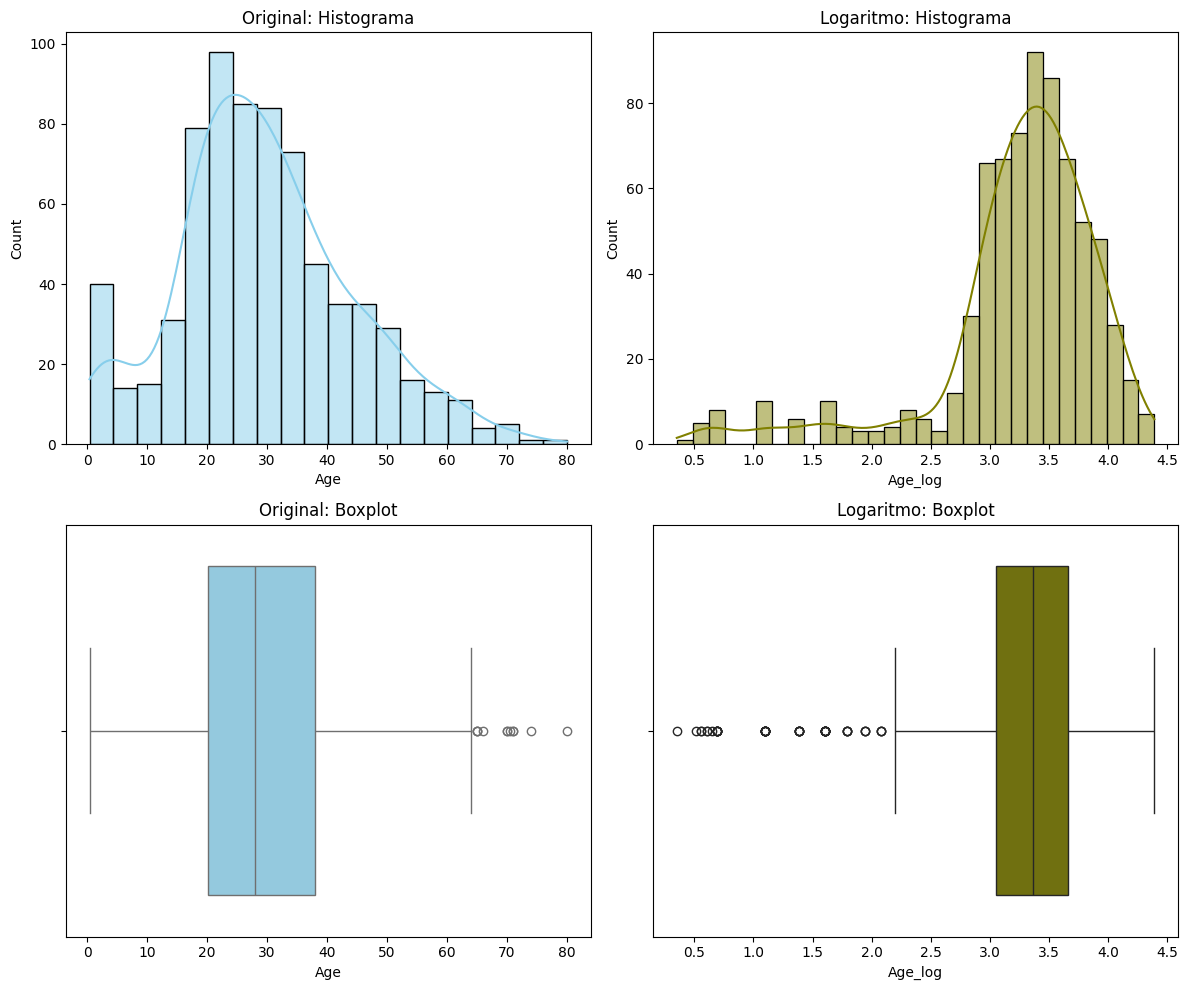

In [ ]:
#Age
comparar_transformacion(df['Age'], df['Age_log'], 'Logaritmo')

# Conclusión General

**→ En este proyecto, se implementó un pipeline de preprocesamiento robusto que incluyó:**

* Tratamiento Numérico: Aplicación de Estandarización (Z-score) para uniformar magnitudes y Transformación Logarítmica para mitigar el sesgo en variables financieras (como Fare) o la edad de personas (Age).

* Tratamiento Categórico: Uso de One-Hot Encoding para variables nominales y Ordinal Encoding para jerárquicas, convirtiendo texto ('Embarked', 'Sex') en vectores numéricos procesables.

* Limpieza: Identificación y gestión de valores atípicos mediante el análisis de boxplots.

* Comparación: Datos originales y escalados.


**¿Qué técnicas fueron más útiles y por qué?**


* La Estandarización (StandardScaler): Fue la más útil para la estabilidad del modelo. Al centrar los datos en 0, permitimos que algoritmos supervisados o Regresión Logística calculen coeficientes de manera mucho más eficiente y precisa.

* La normalización: Es fundamental seguir el mismo proceso de "aprender" del entrenamiento y "aplicar" al test para mantener la integridad del modelo. Transformamos las características escalándolas a un rango fijo, usualmente [0, 1]. A diferencia de la estandarización, esta técnica no centra los datos en cero, sino que los comprime entre un mínimo y un máximo definidos.

* Logaritmo en 'Fare' y 'Age': Fue clave para reducir la varianza extrema. Al "acercar" los precios de los tickets de lujo a los estándar, el modelo pudo aprender patrones generales en lugar de obsesionarse con unos pocos pasajeros millonarios.